**Question 7.1: Linear algebra exercises**

In [12]:
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv

np.set_printoptions(suppress = True)

M = np.array([1, 2, 3, 0, -4, 1, 0, 3, -1]).reshape(3, 3)
print(f" M is {M}.")


det = la.det(M)  #calculating the determinant
print(f" The determinant of M is: {det:.6f}")

b = np.array([2, 2, -1])
Minv = inv(M)  #calculating the inverse of M

#x is inv(A) * b
xyz = Minv@b  #calculating x
print(f"\nSolution: x, y, z = {xyz}")
#other way (faster)
xyz2 = la.solve(M, b)
print(xyz2)

#if orthoganal, Ainv = Atransposed

Mtransp = M.T
np.allclose(M.T, inv(M))
#this gives false, so this matrix is not orthoganal


#Finding the eigenvectors and eigenvalues
Lambda, v = la.eig(M)
print(f" Lambda: {Lambda}")  #is the eigenvalue
print(f" \nEigenvectors: \n{v}")

 M is [[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]].
 The determinant of M is: 1.000000

Solution: x, y, z = [10. -1. -2.]
[10. -1. -2.]
 Lambda: [ 1.         -4.79128785 -0.20871215]
 
Eigenvectors: 
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


*Question 7.2: Rotation matrices*

In [32]:
import numpy as np
from math import *

def Ex(angle):
    radians = np.deg2rad(angle)
    ex = np.array([1, 0, 0, 0, cos(radians), sin(radians), 0, -sin(radians), cos(radians)]).reshape(3, 3)
    return ex
print(f"\nEx(33)=\n{Ex(33)}")

def Ey(angle):
    radians = np.deg2rad(angle)
    ey = np.array([cos(radians), 0, -sin(radians), 0, 1, 0, sin(radians), 0, cos(radians)]).reshape(3, 3)
    return ey
print(f"\nEy(33)=\n{Ey(33)}")

def Ez(angle):
    radians = np.deg2rad(angle)
    ez = np.array([cos(radians), sin(radians), 0, -sin(radians), cos(radians), 0, 0, 0, 1]).reshape(3, 3)
    return ez
print(f"\nEz(33)=\n{Ez(33)}")


Ex(33)=
[[ 1.          0.          0.        ]
 [ 0.          0.83867057  0.54463904]
 [ 0.         -0.54463904  0.83867057]]

Ey(33)=
[[ 0.83867057  0.         -0.54463904]
 [ 0.          1.          0.        ]
 [ 0.54463904  0.          0.83867057]]

Ez(33)=
[[ 0.83867057  0.54463904  0.        ]
 [-0.54463904  0.83867057  0.        ]
 [ 0.          0.          1.        ]]


**Question 7.3: Applying a rotation matrix**

In [67]:
from numpy.linalg import norm

def Ex(angle):
    radians = np.deg2rad(angle)
    ex = np.array([1, 0, 0, 0, cos(radians), sin(radians), 0, -sin(radians), cos(radians)]).reshape(3, 3)
    return ex

def Ey(angle):
    radians = np.deg2rad(angle)
    ey = np.array([cos(radians), 0, -sin(radians), 0, 1, 0, sin(radians), 0, cos(radians)]).reshape(3, 3)
    return ey

def Ez(angle):
    radians = np.deg2rad(angle)
    ez = np.array([cos(radians), sin(radians), 0, -sin(radians), cos(radians), 0, 0, 0, 1]).reshape(3, 3)
    return ez


E = Ez(180-123)@Ey(90-27.4)@Ez(192.25)
print(f" The combined matrix is: {E}")

#Proving orthoganality
np.allclose(E@E.T, np.identity(3))
row1 = sum(E[0]**2)
row2 = sum(E[1]**2)
row3 = sum(E[2]**2)
print(row1, row2, row3)

print(f" So the combined matrix is a rotation matrix")

#Finding the eigenvectors and eigenvalues
Lambda, v = la.eig(M)
print(f" \nLambda: {Lambda}")  #is the eigenvalue
print(f" \nEigenvectors: \n{v}")

def v(alfa, beta):
    a = np.deg2rad(alfa)
    b = np.deg2rad(beta)
    r = np.array([cos(a)*cos(b), cos(b)*sin(a), sin(b)])
    return r
    
print(f"\nSo v is: ")
print (v(192.25, 27.4))
print(f"The norm is: {norm(v(192.25, 27.4))}")
print()

v2 = E @ v(192.25, 27.4)
print(v2)

 The combined matrix is: [[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
1.0 1.0 1.0
 So the combined matrix is a rotation matrix
 
Lambda: [ 1.         -4.79128785 -0.20871215]
 
Eigenvectors: 
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]

So v is: 
[-0.86760081 -0.1883746   0.46019978]
The norm is: 1.0

[0. 0. 1.]


*Question 7.4: Linear interpolation*

In [2]:
import numpy as np

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

X= float(input("Enter a value for X here: "))

slicedx = x[1:3]
slicedy = y[1:3]

Y = slicedy[0] + ((slicedy[1]-slicedy[0]) * ( X - slicedx[0]) / (slicedx[1] - slicedx[0]))

print(f"So the interpolated value for Y is {Y}.")

np.interp(2.5, x, y)

Enter a value for X here:  2.5


So the interpolated value for Y is 0.5909090909090908.


np.float64(0.5909090909090908)

**Question 7.5: Interpolating polynomial**

[-2.17117476e-04  1.09925609e-02 -2.39059756e-01  2.91867714e+00
 -2.19331359e+01  1.04544074e+02 -3.13633556e+02  5.65812237e+02
 -5.51003146e+02  2.18582332e+02]
[0.3 0.5 0.7 0.8 1.3 1.6 2.  2.3 2.9 3. ]


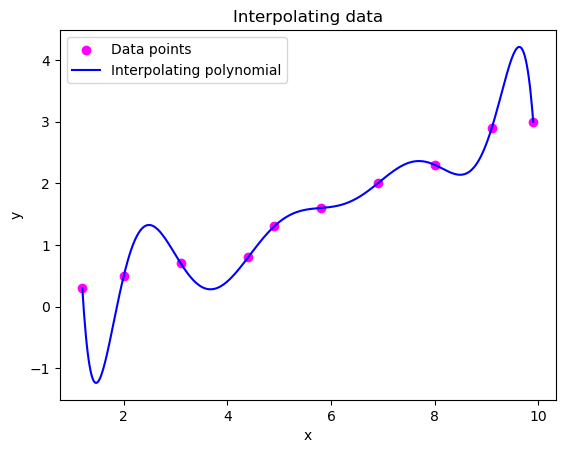

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import show

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])


A = []  #making the array
degree = len(x) - 1
for i in x:
    row = []
    for power in range(degree, -1, -1):
        row.append(i**power)
    A.append(row)
#print(A)

A = np.array(A)  #making the 2D array
#print(AA)

a = np.linalg.solve(A, y)
print(a)

p = np.zeros_like(x)
for j, coeff in enumerate(a):
    power = degree - j
    p += coeff * x**power

print(p)  #making the polynomial
        

#Making the plot
fig, frame = plt.subplots()
frame.scatter(x, y, color = 'magenta', label = 'Data points')

x_smooth = np.linspace(min(x), max(x), 500)
p_smooth = np.zeros_like(x_smooth)
for j, coeff in enumerate(a):
    power = degree - j
    p_smooth += coeff * x_smooth**power

frame.plot(x_smooth, p_smooth, color='blue', label='Interpolating polynomial')
frame.set_xlabel('x')
frame.set_ylabel('y')
frame.set_title('Interpolating data')
frame.legend()

show()

**Question 7.6: Cubic splines and OOP**

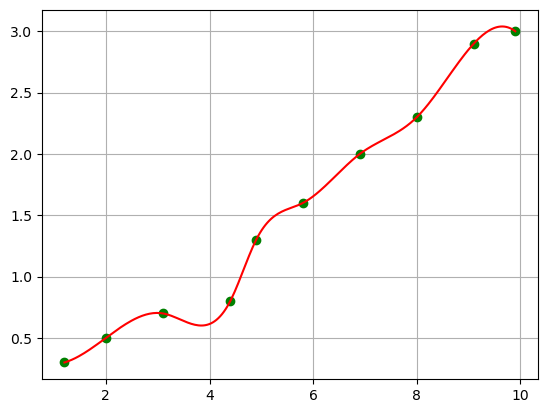


X_new: [1.2        1.65789474 2.11578947 2.57368421 3.03157895 3.48947368
 3.94736842 4.40526316 4.86315789 5.32105263 5.77894737 6.23684211
 6.69473684 7.15263158 7.61052632 8.06842105 8.52631579 8.98421053
 9.44210526 9.9       ]

Linear Y: [0.3        0.41447368 0.52105263 0.60430622 0.68755981 0.72995951
 0.76518219 0.80526316 1.26315789 1.44035088 1.59298246 1.75885167
 1.92535885 2.06889952 2.1937799  2.33732057 2.58708134 2.83684211
 2.94276316 3.        ]

Polynomial Y: [ 0.3        -0.83826789  0.85434845  1.3038763   0.79215632  0.32526034
  0.37229269  0.80582521  1.27016481  1.52888268  1.59854576  1.661384
  1.86570165  2.16919596  2.35698453  2.27306058  2.14109558  2.61799012
  3.92133639  3.        ]

Cubic Spline Y: [0.3        0.39690415 0.53585605 0.6577209  0.70336392 0.64055568
 0.60653564 0.80435582 1.26778032 1.51280832 1.59554079 1.74053006
 1.92704743 2.06908225 2.17389074 2.33011261 2.58065949 2.84363246
 3.01731736 3.        ]


In [39]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip
from scipy.interpolate import interp1d

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(1.2,9.9,250) 
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

#the other plot has some curves that don't have datapoints in them. 
#In essence, it makes extra data up

class interpolation:
    """Can provide interpolation functions of linear, polynomial
    spline interpolation"""

    def __init__(self, x, y):
        if len(x) != len(y):
            print("x and y must have the same length")
        self.x = np.array(x)
        self.y = np.array(y)
        self.degree = len(x) - 1
        self.poly_coeffs = None
        self.spline_func = None

    def compute_polynomial(self):  #making the polynomial
        A = []
        for xi in self.x:
            row = [xi**p for p in range(self.degree, -1, -1)]
            A.append(row)
        A = np.array(A)
        self.poly_coeffs = np.linalg.solve(A, self.y)

    def eval_polynomial(self, x_values):  #evaluating the polynomial
        if self.poly_coeffs is None:
            self.compute_polynomial()
        p = np.zeros_like(x_values, dtype=float)
        for j, coeff in enumerate(self.poly_coeffs):
            power = self.degree - j
            p += coeff * x_values**power
        return p

    def eval_linear(self, x_values):
        f_linear = interp1d(self.x, self.y, kind='linear')
        return f_linear(x_values)

    def eval_spline(self, x_values):
        if self.spline_func is None:
            self.spline_func = interp1d(self.x, self.y, kind='cubic')
        return self.spline_func(x_values)

    def evaluate(self, x_values, method='polynomial'):
        x_values = np.array(x_values)
        if method.lower() == 'polynomial':
            return self.eval_polynomial(x_values)
        elif method.lower() == 'linear':
            return self.eval_linear(x_values)
        elif method.lower() == 'spline':
            return self.eval_spline(x_values)
        else:
            print("method must be 'linear', 'polynomial', or 'spline'")

   # def plot(self, num_points=500):
       # x_smooth = np.linspace(min(self.x), max(self.x), num_points)
        #plt.figure(figsize=(8,5))
        #plt.scatter(self.x, self.y, color='red', label='Data points')

        # Plot each interpolation
        #plt.plot(x_smooth, self.eval_linear(x_smooth), label='Linear', color='green')
        #plt.plot(x_smooth, self.eval_polynomial(x_smooth), label='Polynomial', color='blue')
        #plt.plot(x_smooth, self.eval_spline(x_smooth), label='Cubic Spline', color='orange')

        #plt.xlabel('x')
        #plt.ylabel('y')
        #plt.title('Interpolation Comparison')
        #plt.legend()
        #plt.grid(True)
        #plt.show()


x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

interp = interpolation(x, y)

# Evaluate at a new set of points
#x_new = np.linspace(min(x), max(x), 20)
#y_linear = interp.evaluate(x_new, method='linear')
#y_poly = interp.evaluate(x_new, method='polynomial')
#y_spline = interp.evaluate(x_new, method='spline')

# Print results
print(f"\nX_new:", x_new)
print(f"\nLinear Y:", y_linear)
print(f"\nPolynomial Y:", y_poly)
print(f"\nCubic Spline Y:", y_spline)

# Plot all methods
#interp.plot()

**Question 7.7: Bilinear interpolation**

In [40]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)


I = np.array([[2.0, 4.1], [2.5, 3.8]])
print(I)

row_y = 0.7 # Row position is y value
col_x = 0.2 # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


*Question 7.9: Distinguish Linear- and nonlinear models*

In [ ]:
import numpy as np

#???

**Question 7.10: Fitting the Lemaitre-Hubble relation**

====== LEASTSQ RESULTS ==========
Params:                          [69.93805979 64.13233494]
Unscaled standard error(s):      [47.32288249  1.52711792]
Scaled standard error(s):        [348.23437453  11.23758582]
Degrees of freedom:              11
Chi^2 min:                       595.6533407328835
Reduced Chi squared:             54.15030370298941
Iterations:                      Not returned by leastsq()
Number of function evaluations:  7
 
Intercept beta0 = 69.9377803016813, slope beta1 = 64.13234247590542


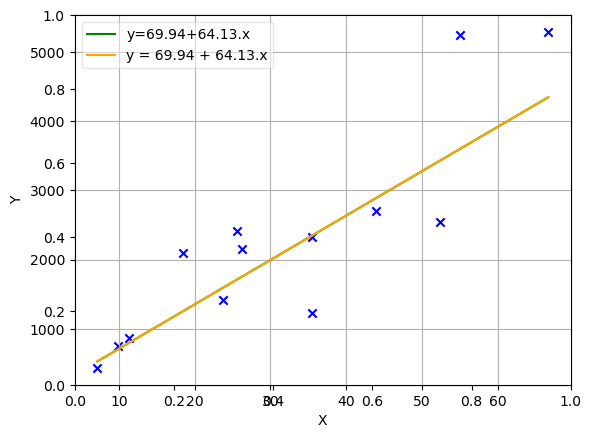

In [36]:
import scipy 
from scipy.optimize import leastsq, curve_fit
import numpy as np
from matplotlib.pyplot import subplots, show, figure
import matplotlib.pyplot as plt
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data = np.asarray(data)
x = data[0::4]; y = data[1::4]
sigx= data[2::4]; sigy= data[3::4]


#using leastsq
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (x, y, sigy)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results


# Convert unscaled standard errors to scaled standard errors
# No need to understand this code
if not pcov is None:
    # Note that 'fvec' are residuals, not function
    # values according to the documentation
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic
    dof = len(fvec) - len(beta)              # Number of degrees of freedom
    # Uncertainties for unweighted data
    sderr = perror * np.sqrt(chi2/dof)

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_lsq = beta


def model2(x, gamma0, gamma1):
    """The model with parameters a and b."""
    return gamma0 + gamma1 * x



#using curve_fit

gamma, pcov = curve_fit(model2, x, y, sigma = sigy)
print(f" \nIntercept beta0 = {gamma[0]}, slope beta1 = {gamma[1]}")

# Calculate end points for the best straight line
X = np.array([x.min(),x.max()])
Y = model2(X, gamma[0], gamma[1])


fig, frame = plt.subplots()

frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='x', color = 'blue')
frame.set_xlabel('X')
frame.set_ylabel('Y')
label2 = f"y={gamma[0]:.2f}+{gamma[1]:.2f}.x"
label1 = f"y = {beta[0]:.2f} + {gamma[1]:.2f}.x"
xmin = x.min(); xmax = x.max()
ymin = model(beta_lsq,xmin); ymax = model(beta_lsq,xmax)

frame.plot(X, Y, label=label2, color='green')
frame.plot([xmin, xmax], [ymin, ymax], label=label1, color='orange')
frame.legend(fancybox=True, framealpha=0.5)
frame.grid(True)



show()

*Question 7.12: Image processing optical data (optional)*

**Question 7.14: Branching**